# In this notebook: 

A overview of how to construct DKIST coordinates from the fits headers. 

If I find any changes, I'll update this notebook and ping you all on Discord! 

**A table of which keywords change slit-to-slit and which ones are FIXED over the whole dataset:**


**KEYWORD DOESN'T CHANGE :**

| Keyword doesn't change      | Desciption |
| -----------                                        | ----------- |
| CDELT1/CDELT3                                      | Pixel scale (i.e. distance between adjacent pixels)       |
| DNAXIS3/DNAXIS1                                    | Number of pixels along each axis.                         |
| PCi_j                                              | Element of transformation matrix (for rotations/skews).   | 

**KEYWORD CHANGES :**

| Keyword Changes (need to update slit-to-slit)      | Description |
| -----------                                        | ----------- |
| CRVAL1/CRVAL3                                      | Position of reference pixel in arcsec                   |
| CRPIX1/CRPIX3                                      | Distance to reference pixel in units of pixel indices   |
| DATE-AVG                                           | Average time of slit observation | 

In [ ]:
import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt

from sunpy.net import Fido, attrs as a
import dkist
from sunpy import map as map

import os

from astropy.time import Time
import astropy.units as u

In [7]:
# 1. Read in the paths/numbe of fits files. This is just to get a sense of how many files we have and what the headers look like.
# Also, read in a single fits header to pull out some impotant metadata.

path_to_local_fits = '/Users/jamescrowley/Documents/summer_2026/research/pid_3_35/XVNDZY/'

all_fits = [x for x in sorted(os.listdir(path_to_local_fits)) if '.fits' in x]

test_header = fits.open(path_to_local_fits + all_fits[0])[1].header

n_fits = len(all_fits)

In [15]:
# reading in the continuum data using sunpy. We can also do this with the fits slits (and in the real version we'll want to do it that way - this is SLOW)
# But for now, easier/simpler to do:

data_path = '/Users/jamescrowley/Documents/summer_2026/research/pid_3_35/XVNDZY/'


asdf_path = '/Users/jamescrowley/Documents/summer_2026/research/pid_3_35/XVNDZY/' + [file_path for file_path in os.listdir(data_path) if '.asdf' in file_path][0]
ds = dkist.load_dataset(asdf_path)
data = ds[0, :, 100, :].data # raster repeat #1, all slit positions, 100th wavelength, all positions along the slit.
data_numpy = np.array(data)
print(data_numpy.shape)

(1500, 2555)


In [8]:
time = Time(test_header['DATE-AVG'])
print(time)
print(time + 1*u.hour)

# grab a HMI dataset to work with. If you need a reminder of how to use Fido, check out the Fido tutorial in the package notebook.
results = Fido.search(a.Instrument.hmi, a.Physobs('intensity'), a.Time(time - 1*u.minute, time + 1*u.minute))
print(results)
hmi_files = Fido.fetch(results, site="NSO")

2025-09-18T19:34:30.006
2025-09-18T20:34:30.006
Results from 1 Provider:

3 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: https://docs.virtualsolar.org/wiki/VSOHealthReport

       Start Time               End Time        Source Instrument    Wavelength    Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                      Angstrom                                                                         Mibyte 
----------------------- ----------------------- ------ ---------- ---------------- -------- --------- -------- ------------ ------------- ----------- --------
2025-09-18 19:33:32.000 2025-09-18 19:33:33.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2025-09-18 19:34:17.000 2025-09-18 19:34:18.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          409

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

179.92984


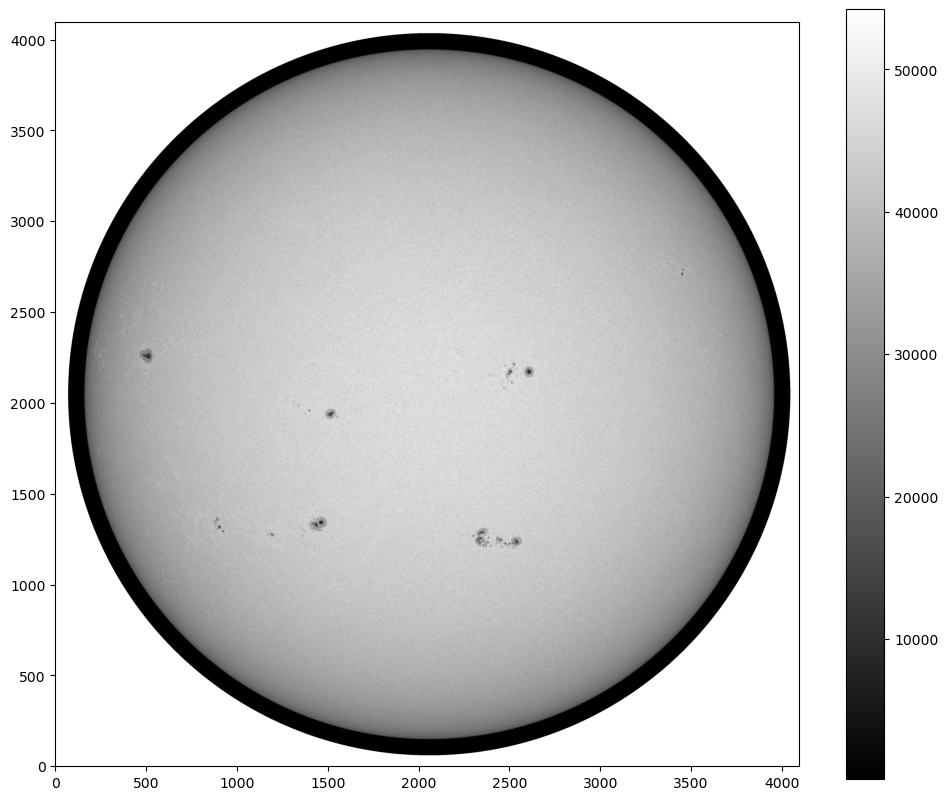

In [12]:
# Read in the HMI data and header for later use.

test_hmi_data = fits.open(hmi_files[0])[1].data
test_hmi_header = fits.open(hmi_files[0])[1].header

# one important keyword: CROTA2, which gives the rotation of the image relative to solar north. This is important for our coordinate transformations later on.
print(test_hmi_header['CROTA2'])

# reading in the coordinates using sunpy's map module. 
# This is a bit of a hack, but it works and is a good way to get the coordinates out of the header without having to parse the header ourselves.
# We only need to do this once, since all the HMI files will have the same coordinates.

test_hmi_data = fits.open(hmi_files[0])[1].data
test_hmi_header = fits.open(hmi_files[0])[1].header

hmi = map.Map(hmi_files[0])

# taking things out of Sunpy because i am sunpy hater
hmix = map.all_coordinates_from_map(hmi).Tx.value
hmiy = map.all_coordinates_from_map(hmi).Ty.value
hmi_data = hmi.data


# flipping the HMI data (with [::-1, ::-1]) because of the CROTA2 keyword. 
plt.figure(figsize = [12, 10])
plt.imshow(test_hmi_data[::-1, ::-1], cmap = 'grey', origin='lower')
plt.colorbar()

In [20]:
# Reading in fits keywords that DON'T change:

cdelt1 = test_header['CDELT1']
cdelt3 = test_header['CDELT3']

nx = test_header['DNAXIS3']
ny = test_header['DNAXIS1']

pc1_1 = test_header['PC1_1']
pc1_3 = test_header['PC1_3']
pc3_1 = test_header['PC3_1']
pc3_3 = test_header['PC3_3']

pcs = [pc1_1, pc1_3, pc3_1, pc3_3]


In [21]:
# Assembling coordinates (in my best current undestanding of the fits header keywords).

coordinates = np.zeros((nx, ny, 2))

for i, slit_i in enumerate(all_fits[:nx]):
    temp_header = fits.open(path_to_local_fits + slit_i)[1].header

    crval1 = temp_header['CRVAL1']
    crval3 = temp_header['CRVAL3']

    crpix1 = temp_header['CRPIX1']
    crpix3 = temp_header['CRPIX3']

    indices = np.linspace(1, ny, ny, dtype = int)

    slit_coords_x = crval3 + cdelt3 * (pc3_3 * (i - crpix3) + pc3_1 * (indices - crpix1))
    slit_coords_y = crval1 + cdelt1 * (pc1_3 * (i - crpix3) + pc1_1 * (indices - crpix1))

    coordinates[i, :, 0] = slit_coords_x
    coordinates[i, :, 1] = slit_coords_y

In [22]:
print(nx, ny)

1500 2555


In [23]:
print(coordinates.shape)

(1500, 2555, 2)


Text(0, 0.5, 'Solar Y (arcsec)')

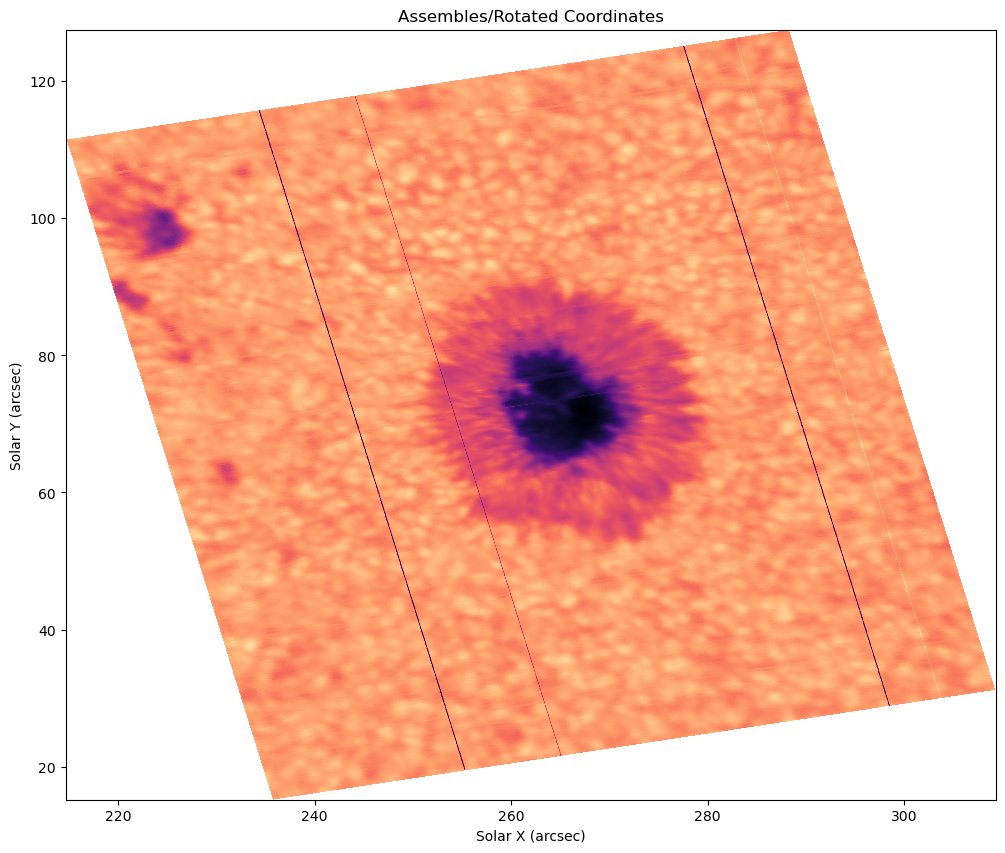

In [25]:
plt.figure(figsize = [12, 10])
plt.title('Assembles/Rotated Coordinates')
plt.pcolormesh(coordinates[:, :, 0], coordinates[:, :, 1], data_numpy, cmap = 'magma', shading = 'nearest')

plt.xlabel('Solar X (arcsec)')
plt.ylabel('Solar Y (arcsec)')

(-64.80299125148389, 207.49381830890349)

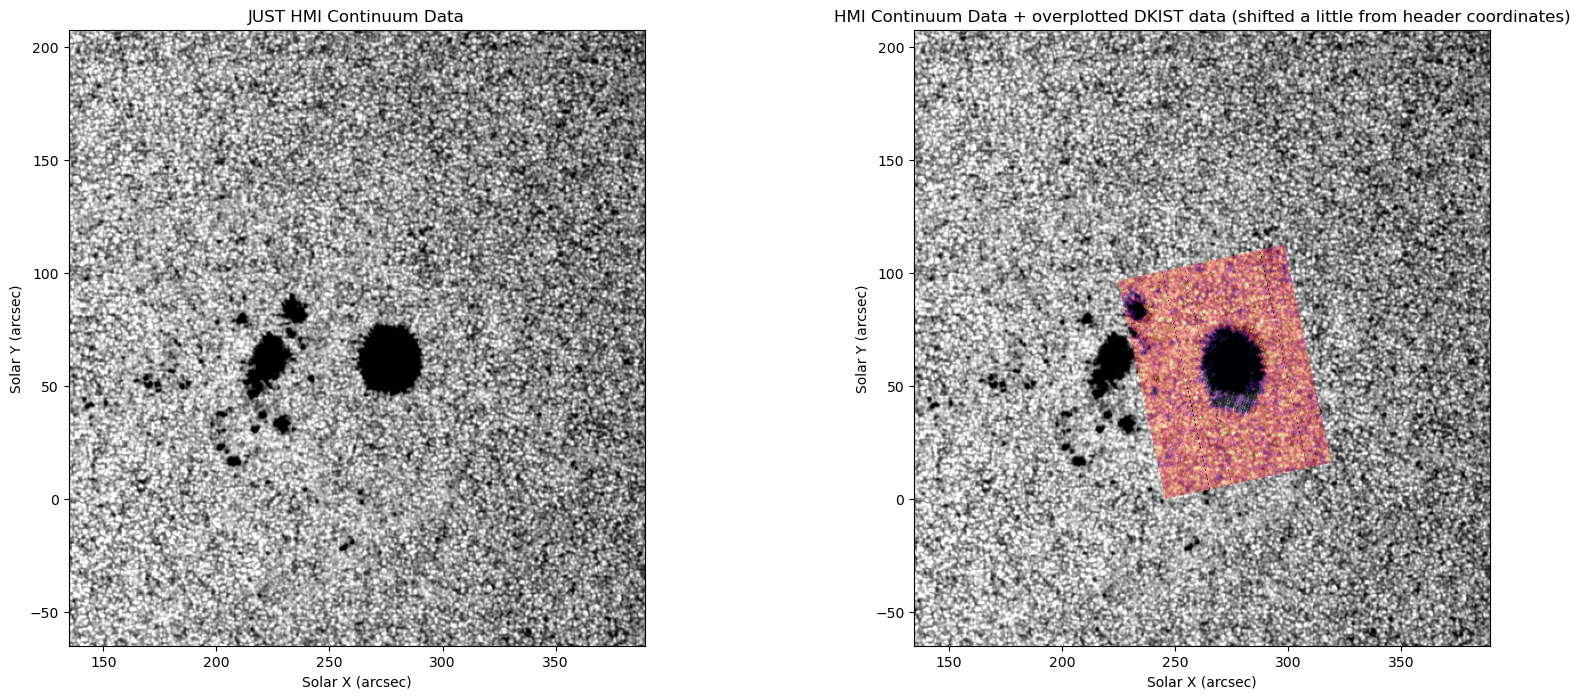

In [37]:
delta = 80

plot_coords = np.copy(coordinates)

# We need to shift the coordiantes a little bit from their header positions.
# I think this is becuase of the error in the header, but also might be because of my misunderstanding of the header keywords. 
# Will check on this! 
plot_coords[:, :, 0] += 10
plot_coords[:, :, 1] -= 15

plt.figure(figsize = [20, 8])


plt.subplot(1,2,1)

plt.title('JUST HMI Continuum Data')

plt.imshow(test_hmi_data[::-1, ::-1]/np.nanmax(test_hmi_data),
            cmap = 'grey',
            vmin = 0.75,
            vmax = 0.9,
            extent=[hmix[-1, -1],
                    hmix[0, 0], 
                    hmiy[-1, -1], 
                    hmiy[0, 0]],
            origin = 'lower'
            )

plt.xlabel('Solar X (arcsec)')
plt.ylabel('Solar Y (arcsec)')

plt.xlim(np.min(coordinates[:, :, 0]) - delta, np.max(coordinates[:, :, 0]) + delta)
plt.ylim(np.min(coordinates[:, :, 1]) - delta, np.max(coordinates[:, :, 1]) + delta)

plt.subplot(1,2,2)

plt.title('HMI Continuum Data + overplotted DKIST data (shifted a little from header coordinates)')

plt.imshow(test_hmi_data[::-1, ::-1]/np.nanmax(test_hmi_data),
            cmap = 'grey',
            vmin = 0.75,
            vmax = 0.9,
            extent=[hmix[-1, -1],
                    hmix[0, 0], 
                    hmiy[-1, -1], 
                    hmiy[0, 0]],
            origin = 'lower'
            )


plt.pcolormesh(plot_coords[..., 0][::3, ::3], 
               plot_coords[..., 1][::3, ::3],
               data_numpy[:, :][::3, ::3],
               vmin = 0.75,
               vmax = 1.05,
               cmap = 'magma',
               alpha = 0.5,
               shading = 'nearest')

plt.xlabel('Solar X (arcsec)')
plt.ylabel('Solar Y (arcsec)')


plt.xlim(np.min(coordinates[:, :, 0]) - delta, np.max(coordinates[:, :, 0]) + delta)
plt.ylim(np.min(coordinates[:, :, 1]) - delta, np.max(coordinates[:, :, 1]) + delta)